## Data loading

In [2]:
import pandas as pd
import os


directory = "Sber-Conditional/Data/"  # set directory path
d = {}
formed = {}

for i, entry in enumerate(os.scandir(directory)):  
    if entry.is_file() and entry.name.endswith('.xlsx'):  # check if it's a file
        # print(entry.name)
        d[entry.name] = pd.read_excel(f"{directory}{entry.name}")
    elif entry.is_file() and entry.name.endswith('.csv'):
        formed[entry.name] = pd.read_csv(f"{directory}{entry.name}")
        

---
## Data prepocessing

In [3]:
global_macros = d["global_macro.xlsx"]
apk_nona = formed["apk_nona.csv"]

In [4]:
global_macros = global_macros.drop(columns=["Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1"])

In [5]:
apk_nona["Date"] = apk_nona["Unnamed: 0"]
apk_nona["Date"] = pd.to_datetime(apk_nona["Date"])

In [6]:
global_macros = global_macros.iloc[3:][::-1].reset_index(drop=True)
global_macros = global_macros.drop(columns=["Date"])
global_macros.index = apk_nona["Date"]

apk_nona = apk_nona.set_index('Date')

In [7]:
assert global_macros.shape[0] == apk_nona.shape[0]

In [8]:
from utils.data_prepocessing import _ensure_monthly_index_and_align_exog, plot_forecaster_feature_importance

apk_nona_en, global_macros_en = _ensure_monthly_index_and_align_exog(apk_nona, global_macros)

---
## Time series aggregation per cluster

In [13]:
from utils.constants import CATEGORY_MAP
import matplotlib.pyplot as plt 


def normalize_series(s: pd.Series, method: str = "index"):
    """
    Normalize a Series. method in {"index", "minmax", "zscore"}.
    - "index": value / first_non_null_value * 100
    - "minmax": (value - min) / (max - min)
    - "zscore": (value - mean) / std
    """
    s = s.copy()
    if method == "index":
        # use first non-null value as base
        first = s.dropna().iloc[0] if not s.dropna().empty else None
        if first is None or first == 0:
            return s * float("nan")
        return s / first * 100.0
    elif method == "minmax":
        lo = s.min()
        hi = s.max()
        if hi == lo:
            return (s - lo)  # all zeros
        return (s - lo) / (hi - lo)
    elif method == "zscore":
        mu = s.mean()
        sigma = s.std()
        if sigma == 0:
            return s - mu
        return (s - mu) / sigma
    else:
        raise ValueError("Unknown normalization method")


def plot_trend_for_cat(df: pd.DataFrame,
                       rolling_window_months: int = 12,
                       require_full_window: bool = True,
                       norm_method: str = 'index') -> None:
    fig, ax = plt.subplots(4, 2, figsize=(19,15))
    cols_to_plot = []
    df.columns = [col.replace("/", " ") for col in df.columns]
    # --- Create category sums ---
    for idx, category in enumerate(set(CATEGORY_MAP.values())):
        # Get all columns belonging to this category that are present in df
        cols = [col for col, cat in CATEGORY_MAP.items() if cat == category and col in df.columns]
    
        if cols:  # only if such columns exist in df
            df[f"{category}_sum"] = df[cols].sum(axis=1)
            # compute rolling sum over specified months
            minp = rolling_window_months if require_full_window else 1
            rolling_col_name = f"{category}_{rolling_window_months}m_sum"
            df[rolling_col_name] = df[f"{category}_sum"].rolling(window=rolling_window_months,
                                                             min_periods=minp).sum()
            norm_monthly = normalize_series(df[f"{category}_sum"], method=norm_method)
            norm_rolling = normalize_series(df[rolling_col_name], method=norm_method)
            idx_plot_y = idx % 4
            idx_plot_x = int(idx >= 4)
            
            fig.patch.set_facecolor('lightgray')
            ax[idx_plot_y, idx_plot_x].grid(axis='x', linestyle=':', alpha=0.6)
            ax[idx_plot_y, idx_plot_x].set_title(f'{category} index stats')
            ax[idx_plot_y, idx_plot_x].set_facecolor('lightgray')
            ax[idx_plot_y, idx_plot_x].plot(df.index, norm_monthly, linewidth=2, color="maroon", label=f'{category} sum')
            ax[idx_plot_y, idx_plot_x].plot(df.index, norm_rolling, linewidth=2, color="steelblue", label=f'roling windw {rolling_window_months} month sum')
            ax[idx_plot_y, idx_plot_x].legend()
    plt.show()

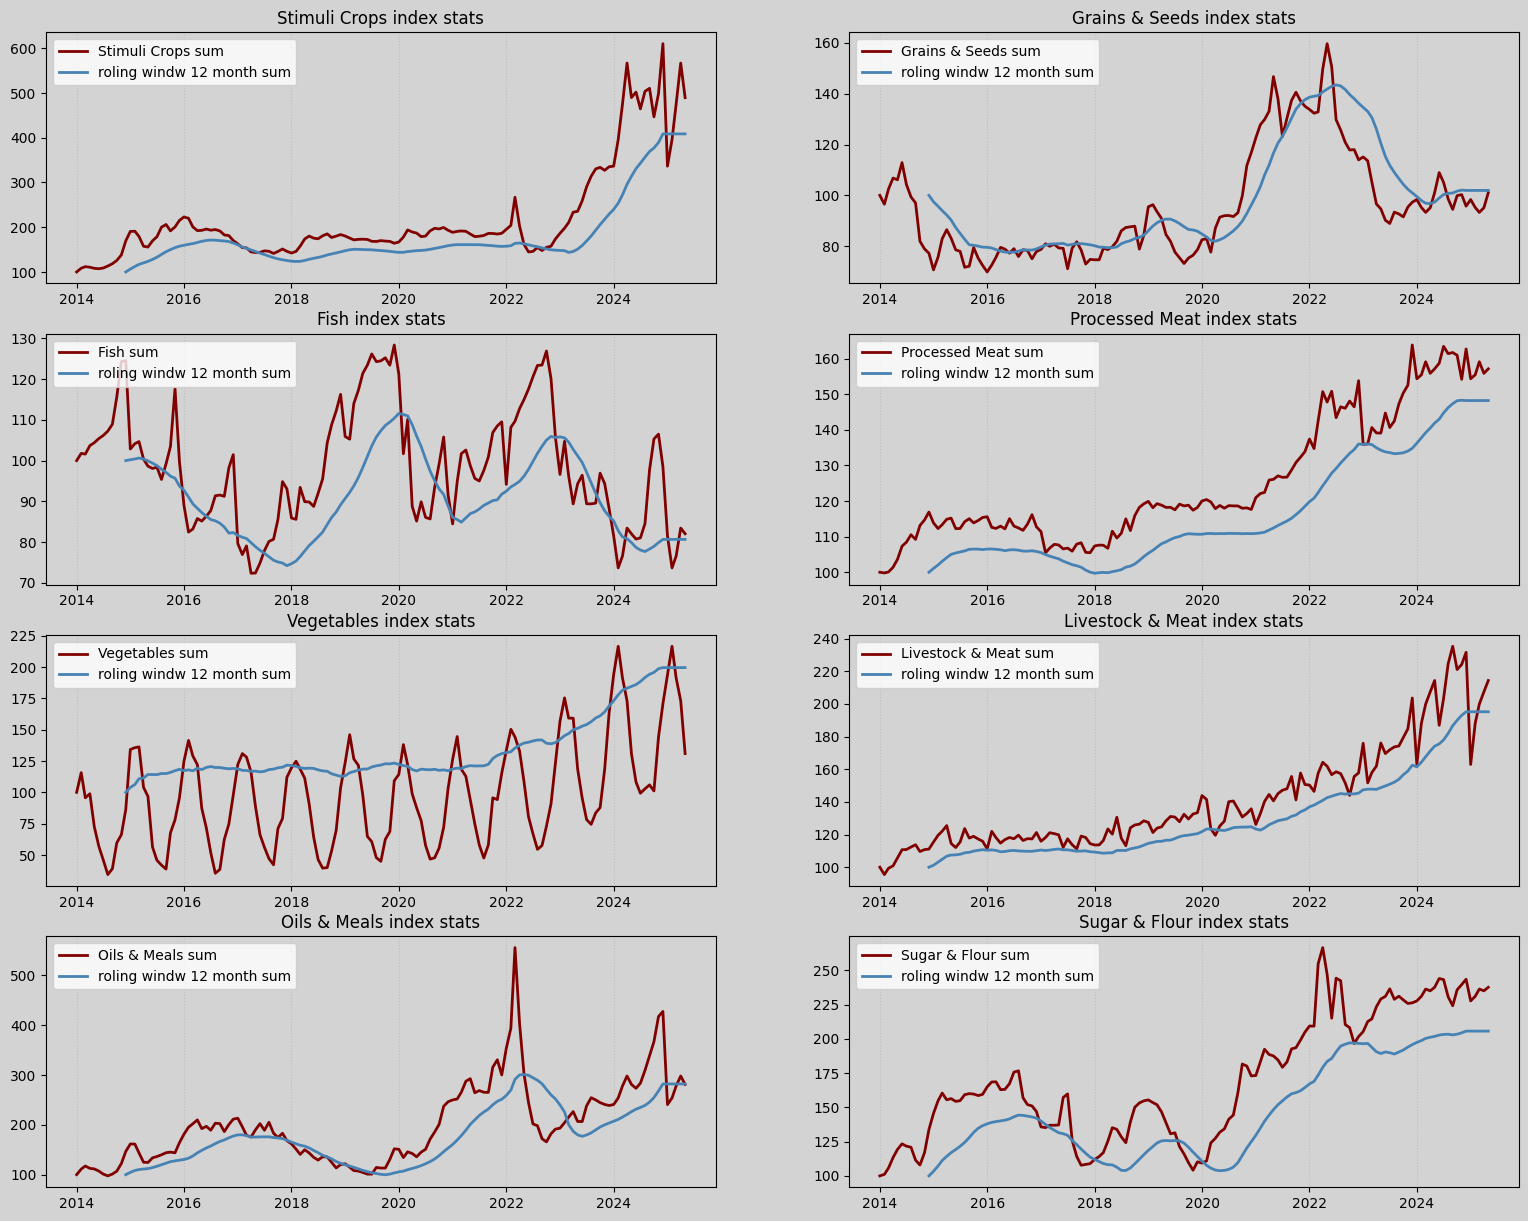

In [33]:
plot_trend_for_cat(apk_nona_en, 12, norm_method="index")

In [15]:
apk_nona_en

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,Fish_sum,Fish_12m_sum,Livestock & Meat_sum,Livestock & Meat_12m_sum,Stimuli Crops_sum,Stimuli Crops_12m_sum,Processed Meat_sum,Processed Meat_12m_sum,Grains & Seeds_sum,Grains & Seeds_12m_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,1447.878788,NaN,484.852870,NaN,2.672163e+05,NaN,571.596360,NaN,817.413751,NaN
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,1473.560606,NaN,463.050970,NaN,2.894242e+05,NaN,570.527210,NaN,788.882961,NaN
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,1471.212121,NaN,481.669150,NaN,2.989678e+05,NaN,572.090620,NaN,837.588143,NaN
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,1501.181818,NaN,488.960860,NaN,2.953990e+05,NaN,579.627080,NaN,873.080043,NaN
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,1511.590909,NaN,512.556390,NaN,2.889496e+05,NaN,592.300650,NaN,867.529817,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,1180.454545,15224.681818,790.013237,12120.627287,8.989631e+05,1.549748e+07,882.217153,10888.922169,803.923643,9695.761058
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,1066.363636,15224.681818,912.430985,12120.627287,1.058022e+06,1.549748e+07,888.523148,10888.922169,778.479784,9695.761058
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,1108.409091,15224.681818,969.207520,12120.627287,1.269732e+06,1.549748e+07,909.539989,10888.922169,762.691952,9695.761058


In [104]:
def plot_preds_on_curve(preds: pd.DataFrame,
                        label: pd.DataFrame,
                        mape_val: str,
                        predictor_name: str,
                        cat_name: str,
                        save_dir: str):
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('lightgray')
    ax.plot(preds.index, preds, color="maroon", label=f"Sum index of {cat_name} preds")
    ax.plot(label.index, label, color="steelblue", label=f"Sum index of {cat_name} label")
    ax.legend()
    ax.set_title(f"Sum index {cat_name} preds vs labels with predictor {predictor_name}; curr mape: {mape_val:.2f}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sum")
    ax.set_facecolor('lightgray')
    plt.savefig(f'{save_dir}/{cat_name}_by_{predictor_name}_sum_index_one_year.png')

In [105]:
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, mae, rmse
import pandas as pd
from typing import Dict, Optional


class ClusterForecaster:
    def __init__(self,
                 cluster_data: pd.DataFrame,
                 macro_data: pd.DataFrame,
                 category_map: Dict[str, str],
                 freq: str = "M"):
        self.cluster_data = cluster_data
        self.macro_data = macro_data
        self.category_map = category_map
        self.freq = freq
        self.scaler_target = Scaler()
        self.scaler_cov = Scaler()
        self.model = None

    def _aggregate_clusters(self) -> pd.DataFrame:
        df = pd.DataFrame(index=self.cluster_data.index)
        for cluster in set(self.category_map.values()):
            cols = [c for c, cat in self.category_map.items()
                    if cat == cluster and c in self.cluster_data.columns]
            if cols:
                df[cluster] = self.cluster_data[cols].sum(axis=1)
        return df

    def _prepare_series(self,
                        target_col: str,
                        train_end: pd.Timestamp = None,
                        covariates: Optional[pd.DataFrame] = None):
        # slice up to train_end
        if train_end is not None:
            mask = self.cluster_data.index <= train_end
            target_slice = self.cluster_data.loc[mask, f"{target_col}_sum"]
            cov_slice = covariates.loc[mask, :]
        else:
            target_slice = self.cluster_data[f"{target_col}_sum"]
            cov_slice = covariates

        target_ts = TimeSeries.from_series(target_slice, freq='M')
        cov_ts = None
        if covariates is not None:
            cov_ts = TimeSeries.from_dataframe(covariates, freq='M')
        return target_ts, cov_ts

    def train(self,
              target_cluster: str,
              additional_cluster: Optional[str] = None,
              use_macro: bool = True,
              past_covariate_lags: int = 12,
              train_end: pd.Timestamp = None,
              model_type: str = "NBEATS",
              **model_kwargs):
        """
        Train model up to train_end (inclusive).
        If train_end is None, use full series except last output chunk.
        """
        # build covariates DataFrame
        cov_df = pd.DataFrame(index=self.cluster_data.index)
        if use_macro:
            cov_df = pd.concat([cov_df, self.macro_data], axis=1)
        if additional_cluster:
            # include lagged additional cluster series
            cov_df[f"{additional_cluster}_lag1"] = self.cluster_data[f"{additional_cluster}_sum"].shift(1)

        # fill missing values (bfill or ffill as needed)
        cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")

        # convert to Darts time series
        target_ts, cov_ts = self._prepare_series(target_cluster, train_end, cov_df)

        # scaling
        # target_ts_scaled = self.scaler_target.fit_transform(target_ts)
        # cov_ts_scaled = None
        # if cov_ts is not None:
        #     cov_ts_scaled = self.scaler_cov.fit_transform(cov_ts[f"{target_cluster}_sum"])
        #     print(cov_ts_scaled)

        # choose model
        if model_type == "NBEATS":
            model = NBEATSModel(input_chunk_length=past_covariate_lags,
                                output_chunk_length=12,
                                **model_kwargs)
        else:
            raise NotImplementedError(f"Model type {model_type} not implemented")

        # fit model
        model.fit(series=target_ts, past_covariates=cov_ts, verbose=True)

        self.model = model
        # store the slices used for training
        self._train_target_ts = target_ts
        self._train_cov_ts = cov_ts
        self._train_end = train_end

    def forecast(self, n: int = 12, covariates_future: Optional[pd.DataFrame] = None):
        """
        Forecast the next n steps beyond training data.
        If covariates_future is provided, it should cover the future period.
        """
        if self.model is None:
            raise RuntimeError("Model not trained yet")

        if covariates_future is not None:
            cov_future_ts = TimeSeries.from_dataframe(covariates_future, freq="M")
            # cov_future_ts = self.scaler_cov.transform(cov_future_ts)
        else:
            cov_future_ts = None

        pred = self.model.predict(n=n, past_covariates=cov_future_ts)
        # pred = self.scaler_target.inverse_transform(pred_scaled)
        return pred

    def backtest(self,
                 target_cluster: str,
                 additional_cluster: Optional[str] = None,
                 use_macro: bool = True,
                 past_covariate_lags: int = 12,
                 start_backtest: pd.Timestamp = None,
                 forecast_horizon: int = 12,
                 model_type: str = "NBEATS",
                 **model_kwargs):
        """
        Do a one-step backtest: train on everything before `start_backtest`, forecast forecast_horizon steps,
        and compare with actuals.
        Returns (predicted_series, actual_series, dict of metrics).
        """
        if start_backtest is None:
            raise ValueError("Please supply a start backtest date")

        # train up to just before backtest
        train_end = start_backtest - pd.offsets.MonthBegin(1)
        self.train(target_cluster=target_cluster,
                   additional_cluster=additional_cluster,
                   use_macro=use_macro,
                   past_covariate_lags=past_covariate_lags,
                   train_end=train_end,
                   model_type=model_type,
                   **model_kwargs)

        # Prepare the covariates for the forecast period
        # covariates_future should be aligned to the next n periods after train_end
        future_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                                   periods=forecast_horizon,
                                   freq="MS")
        cov_future = pd.DataFrame(index=future_idx)
        if use_macro:
            cov_future = pd.concat([cov_future, self.macro_data], axis=1)
        if additional_cluster:
            # use lagged additional cluster’s known values
            # shift by one period so that at time t we use additional_cluster at t-1
            all_add = self.cluster_data[f"{additional_cluster}_sum"].shift(1)
            cov_future[f"{additional_cluster}_lag1"] = all_add.reindex(future_idx)
        cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")

        # forecast
        pred_ts = self.forecast(n=forecast_horizon, covariates_future=cov_future)

        # actual in that period
        actual = self.cluster_data[f"{target_cluster}_sum"].reindex(future_idx)
        actual_ts = TimeSeries.from_series(actual)

        # metrics
        mape_val = mape(actual_ts, pred_ts)
        mae_val = mae(actual_ts, pred_ts)
        rmse_val = rmse(actual_ts, pred_ts)
        plot_preds_on_curve(pred_ts.to_dataframe(),
                            actual_ts.to_dataframe(),
                            mape_val,
                            additional_cluster,
                            target_cluster,
                            "darts_result")
        metrics = {"MAPE": mape_val, "MAE": mae_val, "RMSE": rmse_val}
        pred_ts.to_dataframe().to_csv(f"darts_result_tables/{target_cluster}_by_{additional_cluster}_preds.csv", index=False)

        return pred_ts, actual_ts, metrics


In [ ]:
for predictor_cat in set(CATEGORY_MAP.values()):
    for target_cat in set(CATEGORY_MAP.values()):
        if predictor_cat == target_cat:
            continue
        forecaster = ClusterForecaster(cluster_data=apk_nona_en,
                                       macro_data=global_macros_en,
                                       category_map=CATEGORY_MAP,
                                       freq="M")
        
        start_backtest = pd.Timestamp("2024-05-01")
        
        pred_ts, actual_ts, metrics = forecaster.backtest(
            target_cluster=target_cat,
            additional_cluster=predictor_cat, 
            use_macro=True,
            past_covariate_lags=12,
            start_backtest=start_backtest,
            forecast_horizon=12, 
            model_type="NBEATS",
            n_epochs=200
        )

        print("Metrics:", metrics)

C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\3020471287.py:72: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.726    Total estimat

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=200` reached.
C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\3020471287.py:159: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\3020471287.py:72: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.726    Total estimat

...

Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\3020471287.py:72: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.726    Total estimat

Metrics: {'MAPE': 9.58805809036595, 'MAE': 96.15550659880118, 'RMSE': 113.03726659167737}


C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |                                                                                      | 0/? [00:00<…

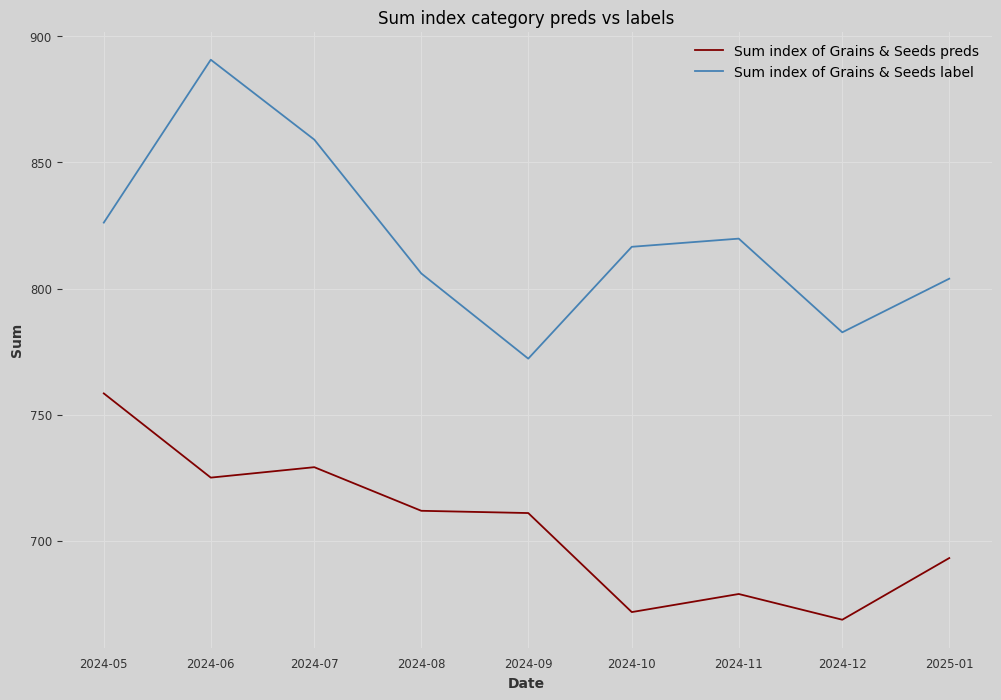

In [96]:
plot_preds_on_curve(pred_ts.to_dataframe(), actual_ts.to_dataframe(), "Grains & Seeds")

In [89]:
print("Predictions:\n", pred_ts.to_dataframe())
print("Actuals:\n", actual_ts.to_dataframe())


Predictions:
             Grains & Seeds_sum
Date                          
2024-05-01          774.245445
2024-06-01          780.380402
2024-07-01          754.874219
2024-08-01          744.763522
2024-09-01          785.003746
2024-10-01          762.228047
2024-11-01          770.837345
2024-12-01          768.831376
2025-01-01          767.900640
Actuals:
             Grains & Seeds_sum
2024-05-01          826.151518
2024-06-01          890.726108
2024-07-01          859.049981
2024-08-01          806.007529
2024-09-01          772.228551
2024-10-01          816.566529
2024-11-01          819.806022
2024-12-01          782.663148
2025-01-01          803.923643


In [87]:
pred_ts

<TimeSeries (Date: 9, component: 1, sample: 1)>
array([[[774.24544477]],

       [[780.38040189]],

       [[754.87421911]],

       [[744.76352151]],

       [[785.0037458 ]],

       [[762.22804667]],

       [[770.8373451 ]],

       [[768.8313758 ]],

       [[767.90064009]]])
Coordinates:
  * Date       (Date) datetime64[ns] 2024-05-01 2024-06-01 ... 2025-01-01
  * component  (component) object 'Grains & Seeds_sum'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
from utils.constants import CATEGORY_MAP


forecaster = ClusterForecaster(cluster_data=apk_nona_en,
                               macro_data=global_macros,
                               category_map=CATEGORY_MAP)

# 1️⃣ Predict cluster using only macro + its lags
forecaster.train(target_cluster="Grains & Seeds", use_macro=True)
forecast_1 = forecaster.forecast_next_year()

# 2️⃣ Predict cluster using macro + another cluster
forecaster.train(target_cluster="Grains & Seeds",
                 additional_cluster="Oils & Meals",
                 use_macro=True)
forecast_2 = forecaster.forecast_next_year()

# 3️⃣ Predict 12-month sliding window using macro + cluster lags only
forecaster.train(target_cluster="Grains & Seeds", use_macro=True)
forecast_3 = forecaster.forecast_next_year()


In [27]:
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from typing import List, Optional, Dict
import pandas as pd
import numpy as np


class ClusterForecaster:
    def __init__(self, 
                 cluster_data: pd.DataFrame,
                 macro_data: pd.DataFrame,
                 category_map: Dict[str, str],
                 freq: str = "M"):
        """
        cluster_data: DataFrame with price columns per product
        macro_data: DataFrame with macroeconomic indicators
        category_map: dict mapping each product to its cluster
        freq: frequency of data ('M' for monthly)
        """
        self.cluster_data = cluster_data
        self.macro_data = macro_data
        self.category_map = category_map
        self.freq = freq
        self.cluster_sums = self._aggregate_clusters()
        self.scaler = Scaler()
        self.model = None

    def _aggregate_clusters(self) -> pd.DataFrame:
        """Aggregate time series into cluster sums."""
        cluster_sums = pd.DataFrame(index=self.cluster_data.index)
        for cluster in set(self.category_map.values()):
            cols = [c for c, cat in self.category_map.items() if cat == cluster and c in self.cluster_data.columns]
            if cols:
                cluster_sums[cluster] = self.cluster_data[cols].sum(axis=1)
        return cluster_sums

    def _prepare_series(self, target_col: str, 
                        regressors: Optional[pd.DataFrame] = None) -> (TimeSeries, Optional[TimeSeries]):
        """Convert to Darts TimeSeries objects."""
        target = TimeSeries.from_series(self.cluster_sums[target_col])
        covariates = None
        if regressors is not None:
            covariates = TimeSeries.from_dataframe(regressors)
        return target, covariates

    def train(self, 
              target_cluster: str,
              additional_cluster: Optional[str] = None,
              use_macro: bool = True,
              model_type: str = "NBEATS",
              past_covariate_lags: int = 12):
        """
        Train a forecasting model.
        - target_cluster: which cluster to predict
        - additional_cluster: optional second cluster to include as regressor
        - use_macro: include macroeconomic features
        - model_type: which Darts model to use
        - past_covariate_lags: number of lags
        """
        # --- prepare covariates ---
        covariates_df = pd.DataFrame(index=self.cluster_sums.index)
        if use_macro:
            covariates_df = pd.concat([covariates_df, self.macro_data, self.cluster_data[f"{target_cluster}_sum"]], axis=1)
        if additional_cluster:
            covariates_df[f"{additional_cluster}_lag"] = self.cluster_sums[additional_cluster].shift(1)
        # fill missing lags
        covariates_df = covariates_df.fillna(method="bfill")
        # --- prepare Darts series ---
        target, covariates = self._prepare_series(target_cluster, covariates_df)

        # scale both
        target = self.scaler.fit_transform(target)
        if covariates:
            covariates = self.scaler.transform(covariates[f"{target_cluster}_sum"])

        # --- train model ---
        model = NBEATSModel(
            input_chunk_length=past_covariate_lags,
            output_chunk_length=12,
            n_epochs=200,
            random_state=42
        )
        model.fit(series=target, past_covariates=covariates, verbose=True)
        self.model = model

    def forecast_next_year(self, n: int = 12) -> TimeSeries:
        """Predict the next n months."""
        if not self.model:
            raise RuntimeError("Model not trained yet.")
        forecast = self.model.predict(n=n)
        return self.scaler.inverse_transform(forecast)


In [30]:
forecast_1

<TimeSeries (Date: 12, component: 1, sample: 1)>
array([[[837.03909705]],

       [[895.97985745]],

       [[915.30758222]],

       [[911.35706736]],

       [[946.64349051]],

       [[933.68179963]],

       [[883.46559073]],

       [[896.26634713]],

       [[866.890408  ]],

       [[862.14383317]],

       [[876.13118552]],

       [[874.40547351]]])
Coordinates:
  * Date       (Date) datetime64[ns] 2025-06-01 2025-07-01 ... 2026-05-01
  * component  (component) object 'Grains & Seeds'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [26]:
apk_nona_en

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,"Мука пшеничная, руб. т","Пшеница 12,5% FOB Ново, $ т",Livestock & Meat_sum,Processed Meat_sum,Stimuli Crops_sum,Fish_sum,Vegetables_sum,Oils & Meals_sum,Grains & Seeds_sum,Sugar & Flour_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,11.66556,281.67,484.852870,571.596360,2.672163e+05,1447.878788,198.08475,74027.447654,817.413751,32.293380
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,11.59769,278.50,463.050970,570.527210,2.894242e+05,1473.560606,229.16299,82295.780217,788.882961,32.644840
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,11.78734,290.75,481.669150,572.090620,2.989678e+05,1471.212121,189.43926,86906.511156,837.588143,34.142270
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,12.26536,291.00,488.960860,579.627080,2.953990e+05,1501.181818,195.83359,83399.250515,873.080043,36.598520
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,12.84780,269.75,512.556390,592.300650,2.889496e+05,1511.590909,143.69519,82598.509165,867.529817,38.517050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,21.35402,240.00,790.013237,882.217153,8.989631e+05,1180.454545,384.05946,178183.579059,803.923643,73.516214
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,21.57677,222.25,912.430985,888.523148,1.058022e+06,1066.363636,428.96817,187975.986635,778.479784,74.599497
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,21.60039,204.00,969.207520,909.539989,1.269732e+06,1108.409091,378.94313,205774.443521,762.691952,76.309481


In [20]:
apk_nona_en.columns

Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб.

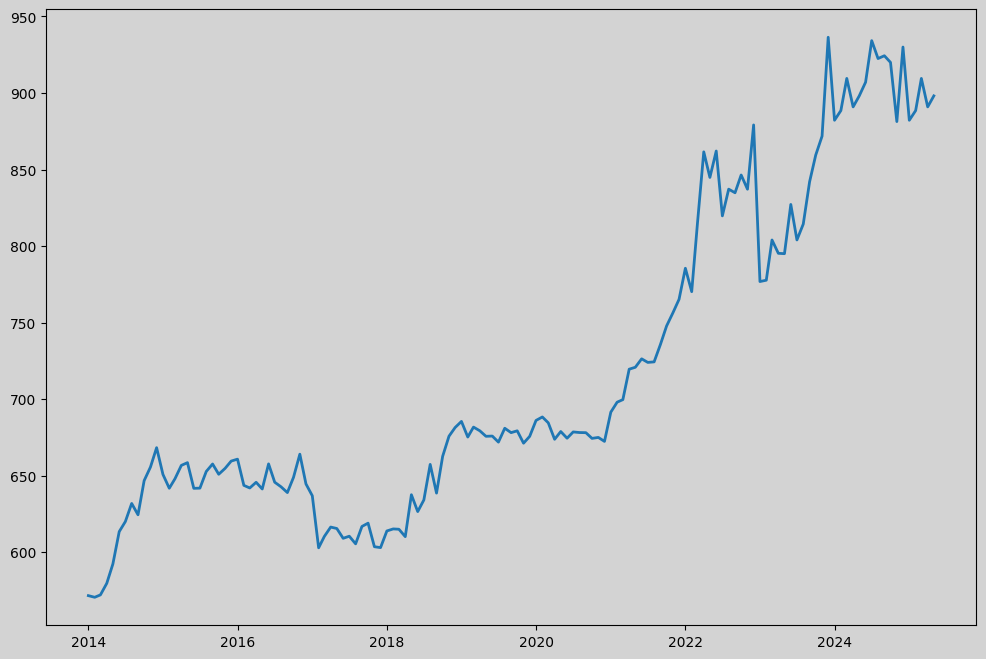

In [19]:
plot_trend_for_cat(apk_nona_en, "Processed Meat")

In [13]:
apk_nona_en

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,"Минтай б/г, Владивосток руб./кг","Минтай б/г, Китай C&F $/т","Сельдь н/р, Владивосток руб./кг","Огурцы тепличные, руб./кг","Томаты тепличные, руб./кг",Колбасы вареные,"Рапс, руб./т","Рапсовое масло EU, $/т","Мука пшеничная, руб./т","Пшеница 12,5% FOB Ново, $/т"
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,50.606061,1370.0,27.272727,109.69276,88.39199,180.118840,10.921240,959.902109,11.66556,281.67
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,46.969697,1400.0,26.590909,133.35480,95.80819,185.952260,11.777070,1025.767008,11.59769,278.50
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,53.939394,1390.0,27.272727,103.82040,85.61886,189.096880,13.147950,1008.712498,11.78734,290.75
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,48.000000,1425.0,28.181818,86.43050,109.40309,191.130370,12.713990,1016.669062,12.26536,291.00
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,47.727273,1440.0,23.863636,61.65754,82.03765,196.688230,11.035150,957.679643,12.84780,269.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,97.045455,1000.0,83.409091,189.07463,194.98483,299.987126,31.943182,940.000000,21.35402,240.00
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,83.181818,900.0,83.181818,199.51996,229.44821,301.577058,32.863636,930.000000,21.57677,222.25
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,80.454545,950.0,77.954545,133.83385,245.10928,306.100714,36.113636,992.000000,21.60039,204.00
